 File loaded successfully.

 First few rows of the dataset:
        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... se

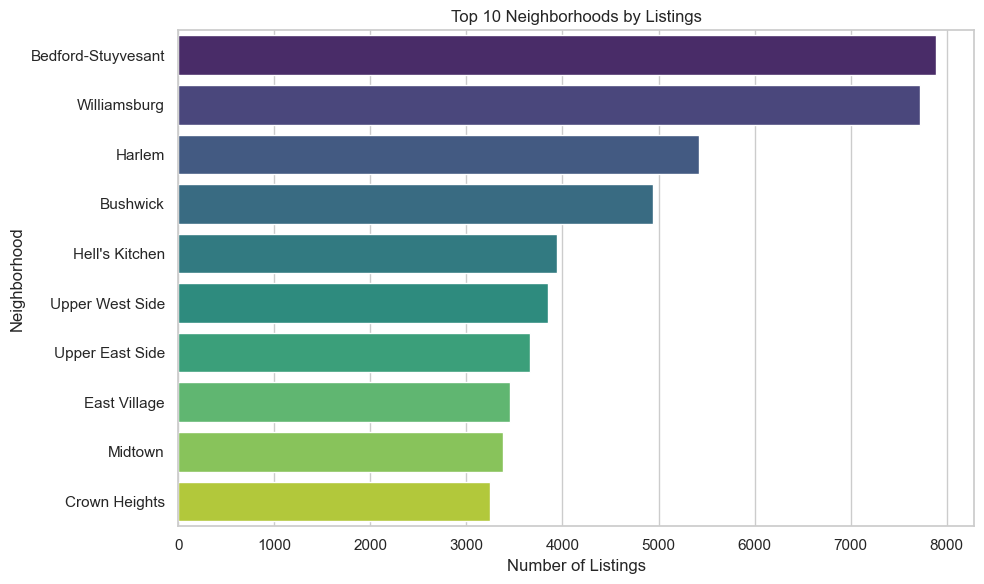

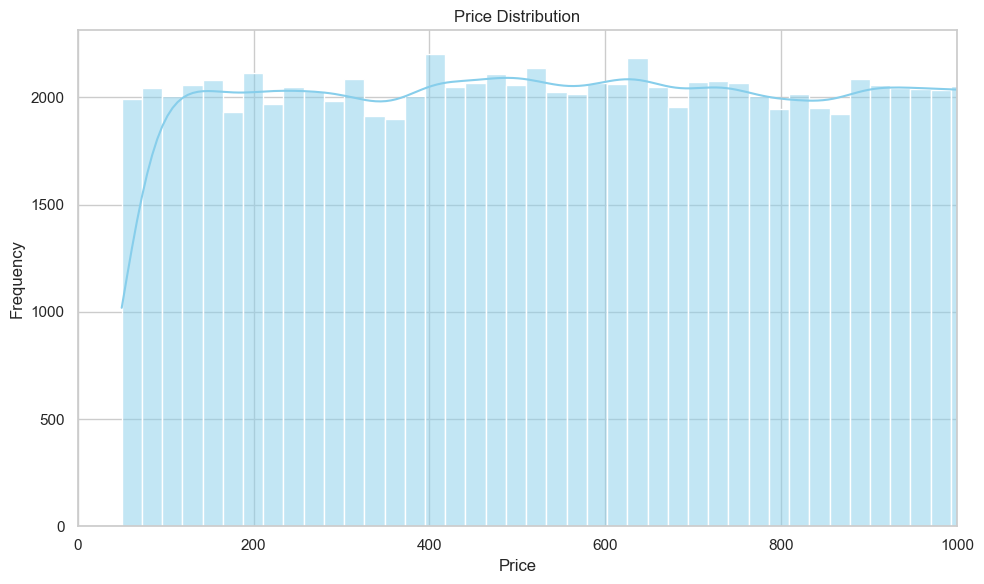

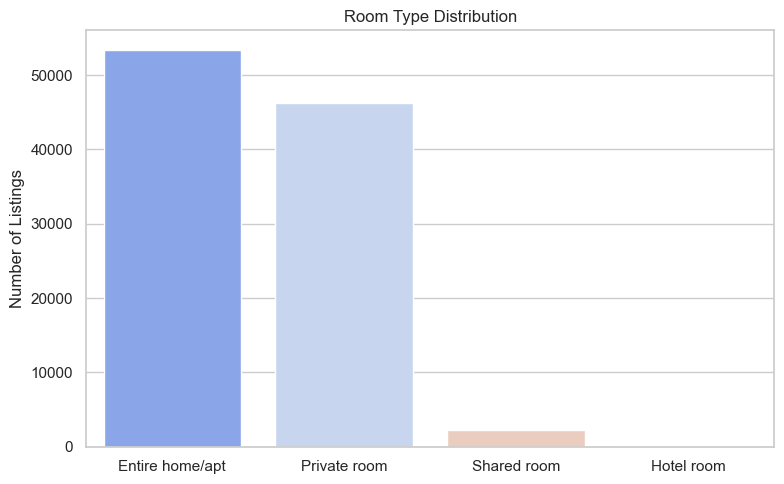

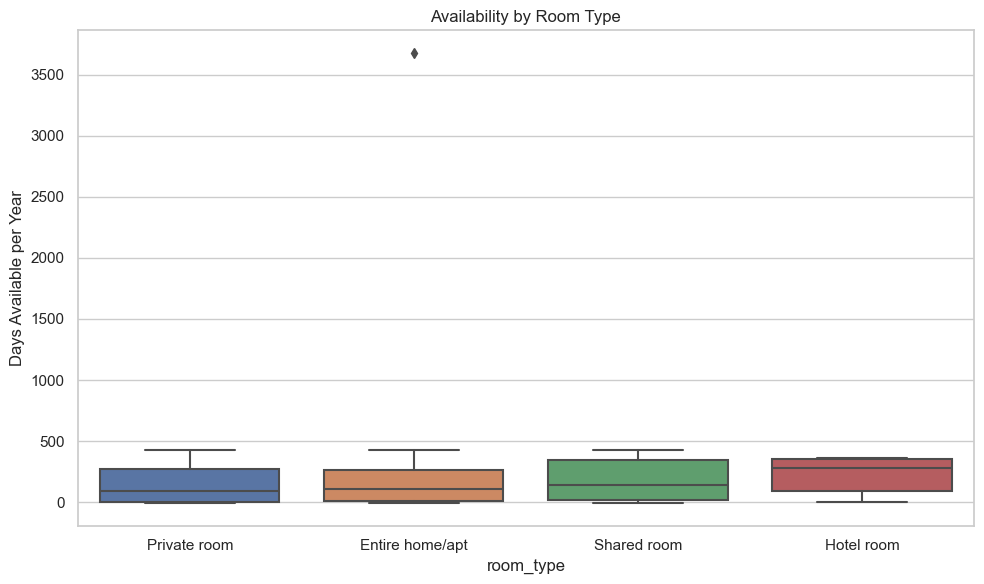

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual style
sns.set(style="whitegrid")

# Load the dataset
try:
    df = pd.read_excel('1730285881-Airbnb_Open_Data.xlsx')
    print(" File loaded successfully.")
except Exception as e:
    print(" Error loading file:", e)
    exit()

# Preview the data
print("\n First few rows of the dataset:")
print(df.head())

# Show column names
print("\n Column names:")
print(df.columns.tolist())

# Check for missing values
print("\n Missing values:")
print(df.isnull().sum())

# Rename columns if needed (example: lowercase)
df.columns = [col.lower().strip().replace(" ", "_") for col in df.columns]

# Check required columns exist
required_cols = ['price', 'room_type', 'neighbourhood', 'availability_365']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f" Missing required columns: {missing_cols}")
    exit()

# Clean and convert price column
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[df['price'].notnull() & (df['price'] > 0)]

# Drop rows with missing critical info
df.dropna(subset=['room_type', 'neighbourhood', 'availability_365'], inplace=True)

#  Top 10 neighborhoods by number of listings
top_neighborhoods = df['neighbourhood'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='viridis')
plt.title('Top 10 Neighborhoods by Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

#  Price distribution
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 1000)  # Adjust based on your data
plt.tight_layout()
plt.show()

#  Room type distribution
room_counts = df['room_type'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=room_counts.index, y=room_counts.values, palette='coolwarm')
plt.title('Room Type Distribution')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

#  Availability analysis
plt.figure(figsize=(10,6))
sns.boxplot(x='room_type', y='availability_365', data=df)
plt.title('Availability by Room Type')
plt.ylabel('Days Available per Year')
plt.tight_layout()
plt.show()
